## Project Overview

In this notebook, I am comparing two classification models (Logistic Regression and Decision Tree) to predict property price categories.  
Instead of predicting the exact sale price (regression), I converted prices into three groups: Low, Medium, and High. This makes it a classification problem and allows easier comparison between models.

The goal is to see which model performs better on this dataset and understand why.

In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Description

This dataset contains real estate transaction data. Since the focus is on sale prices, I filtered the data to keep only sales transactions.  

Some columns had a lot of missing values or were not useful for prediction (like IDs or rental-related columns), so those were removed. This helps reduce noise and improves model performance.

In [47]:
df = pd.read_csv("clean_transactions_pandas.csv")

print("Shape:", df.shape)
print(df["trans_group_en"].value_counts())
df.head()

Shape: (469409, 32)
trans_group_en
Sales        359066
Mortgages     92947
Gifts         17396
Name: count, dtype: int64


,transaction_id,procedure_id,trans_group_id,trans_group_en,procedure_name_en,instance_date,property_type_id,property_type_en,property_sub_type_id,property_sub_type_en,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,Gifts,Grant,2006-10-16,4,Villa,NaN,NaN,...,NaN,0,3162.42,12000000.0,3794.56,NaN,NaN,3.0,1.0,0.0
1,3-9-2019-2944,9,3,Gifts,Grant,2019-11-13,1,Land,NaN,NaN,...,NaN,0,209.09,916659.0,4384.04,NaN,NaN,2.0,4.0,0.0
2,2-13-2001-690,13,2,Mortgages,Mortgage Registration,2001-08-20,2,Building,NaN,NaN,...,NaN,0,1337.80,4519342.0,3378.19,NaN,NaN,1.0,1.0,0.0
3,2-13-2020-9477,13,2,Mortgages,Mortgage Registration,2020-11-30,2,Building,NaN,NaN,...,NaN,0,278.71,2500000.0,8969.90,NaN,NaN,1.0,1.0,0.0
4,2-13-1999-532,13,2,Mortgages,Mortgage Registration,1999-04-26,4,Villa,NaN,NaN,...,NaN,0,3626.93,1900000.0,523.86,NaN,NaN,1.0,1.0,0.0


## Creating Price Categories

Instead of predicting the exact property price, I divided prices into three categories:

- Low price
- Medium price
- High price

I used quantiles so each category has roughly the same number of samples. This helps keep the classification balanced and avoids bias toward one class.

In [48]:
# Keep only Sales transactions
df_sales = df[df["trans_group_en"].astype(str).str.lower() == "sales"].copy()

# Create 3 balanced price classes from actual_worth
df_sales["PriceClass"] = pd.qcut(
    df_sales["actual_worth"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df_sales["PriceClass"].value_counts())
df_sales.head()

PriceClass
Low       119690
High      119689
Medium    119687
Name: count, dtype: int64


,transaction_id,procedure_id,trans_group_id,trans_group_en,procedure_name_en,instance_date,property_type_id,property_type_en,property_sub_type_id,property_sub_type_en,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,PriceClass
5,1-11-2025-36691,11,1,Sales,Sell,2025-09-04,2,Building,NaN,NaN,...,0,211.37,7000000.0,33117.28,NaN,NaN,1.0,2.0,0.0,High
9,1-11-2023-24638,11,1,Sales,Sell,2023-08-18,2,Building,NaN,NaN,...,0,211.35,5000000.0,23657.44,NaN,NaN,14.0,1.0,0.0,High
13,1-11-2002-547,11,1,Sales,Sell,2002-04-01,2,Building,NaN,NaN,...,0,272.21,1000000.0,3673.63,NaN,NaN,1.0,2.0,0.0,Medium
14,1-11-2025-22014,11,1,Sales,Sell,2025-05-29,2,Building,NaN,NaN,...,0,5171.22,73500000.0,14213.28,NaN,NaN,1.0,1.0,0.0,High
16,1-11-2005-1983,11,1,Sales,Sell,2005-10-03,4,Villa,NaN,NaN,...,0,232.26,1500000.0,6458.28,NaN,NaN,3.0,1.0,0.0,Medium


In [49]:
# Target
y = df_sales["PriceClass"]

# Convert date to useful features
df_sales["instance_date"] = pd.to_datetime(df_sales["instance_date"], errors="coerce")
df_sales["year"] = df_sales["instance_date"].dt.year
df_sales["month"] = df_sales["instance_date"].dt.month
df_sales["dayofweek"] = df_sales["instance_date"].dt.dayofweek

# Columns to drop (based on your dataset)
drop_cols = [
    "PriceClass",
    "actual_worth",        # leakage (this is what we're predicting as classes)
    "meter_sale_price",    # leakage (price per meter derived from sale price)
    "transaction_id",      # identifier
    "project_number",      # identifier-like, lots of missing
    "rent_value",          # 100% missing for Sales
    "meter_rent_price",    # 100% missing for Sales
    "building_name_en",    # too many unique values -> OneHot explosion
    "project_name_en",     # too many unique values -> OneHot explosion
    "instance_date"        # we already extracted year/month/dayofweek
]

X = df_sales.drop(columns=[c for c in drop_cols if c in df_sales.columns])

print("X shape:", X.shape)
print("Missing values in X:", X.isna().sum().sum())
X.head()

X shape: (359066, 26)
Missing values in X: 512182


,procedure_id,trans_group_id,trans_group_en,procedure_name_en,property_type_id,property_type_en,property_sub_type_id,property_sub_type_en,property_usage_en,reg_type_id,...,nearest_mall_en,rooms_en,has_parking,procedure_area,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,year,month,dayofweek
5,11,1,Sales,Sell,2,Building,NaN,NaN,Residential,1,...,Dubai Mall,NaN,0,211.37,1.0,2.0,0.0,2025,9,3
9,11,1,Sales,Sell,2,Building,NaN,NaN,Residential,1,...,Dubai Mall,NaN,0,211.35,14.0,1.0,0.0,2023,8,4
13,11,1,Sales,Sell,2,Building,NaN,NaN,Residential,1,...,Dubai Mall,NaN,0,272.21,1.0,2.0,0.0,2002,4,0
14,11,1,Sales,Sell,2,Building,NaN,NaN,Residential / Commercial,1,...,Dubai Mall,NaN,0,5171.22,1.0,1.0,0.0,2025,5,3
16,11,1,Sales,Sell,4,Villa,NaN,NaN,Residential,1,...,Dubai Mall,NaN,0,232.26,3.0,1.0,0.0,2005,10,0


## Data Preprocessing

Before training the models, I prepared the data:

- Missing numeric values were replaced with the median.
- Missing categorical values were replaced with the most frequent value.
- Categorical variables were converted into numbers using one-hot encoding.
- Numeric features were scaled so large values don’t dominate the model.

This step is important because machine learning models need clean numeric data to work properly.

In [50]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['trans_group_en', 'procedure_name_en', 'property_type_en', 'property_sub_type_en', 'property_usage_en', 'reg_type_en', 'area_name_en', 'master_project_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en']
Numeric columns: ['procedure_id', 'trans_group_id', 'property_type_id', 'property_sub_type_id', 'reg_type_id', 'area_id', 'has_parking', 'procedure_area', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3', 'year', 'month', 'dayofweek']


In [51]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (287252, 26) Test: (71814, 26)


## Model Selection

I chose two models for comparison:

**Logistic Regression**
- A simple linear classification model.
- Works well as a baseline model.

**Decision Tree**
- A nonlinear model that makes decisions using rule-based splits.
- Usually better at capturing complex relationships.

Comparing these two helps see whether the dataset behaves more linearly or nonlinearly.

In [53]:
log_reg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=12, min_samples_leaf=30, random_state=42))
])

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree
}

## Model Evaluation

To compare the models, I used:

- Accuracy (overall correctness)
- Precision, Recall, and F1-score
- Confusion matrix

These metrics give a better understanding of how well each model performs across different price categories.

In [54]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("\n" + "="*60)
    print(name)
    print("Accuracy:", round(accuracy_score(y_test, preds), 4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))


Logistic Regression
Accuracy: 0.7758

Confusion Matrix:
 [[20022   346  3570]
 [  676 19212  4050]
 [ 3799  3661 16478]]

Classification Report:
               precision    recall  f1-score   support

        High       0.82      0.84      0.83     23938
         Low       0.83      0.80      0.81     23938
      Medium       0.68      0.69      0.69     23938

    accuracy                           0.78     71814
   macro avg       0.78      0.78      0.78     71814
weighted avg       0.78      0.78      0.78     71814


Decision Tree
Accuracy: 0.8394

Confusion Matrix:
 [[21133   184  2621]
 [  382 20557  2999]
 [ 2780  2564 18594]]

Classification Report:
               precision    recall  f1-score   support

        High       0.87      0.88      0.88     23938
         Low       0.88      0.86      0.87     23938
      Medium       0.77      0.78      0.77     23938

    accuracy                           0.84     71814
   macro avg       0.84      0.84      0.84     71814
weigh

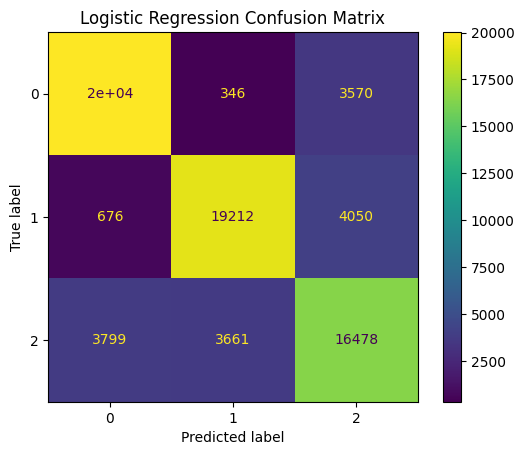

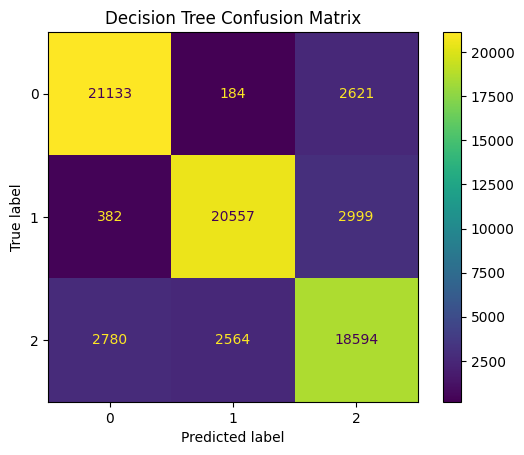

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Logistic Regression confusion matrix
cm_log = confusion_matrix(y_test, preds_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Decision Tree confusion matrix
cm_tree = confusion_matrix(y_test, preds_tree)
ConfusionMatrixDisplay(cm_tree).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Results Discussion

The Decision Tree performed better overall than Logistic Regression.  
It achieved higher accuracy and better F1-scores, especially for the medium price category.

This probably happened because property prices depend on multiple factors in a nonlinear way, and Decision Trees can capture those patterns better than linear models.

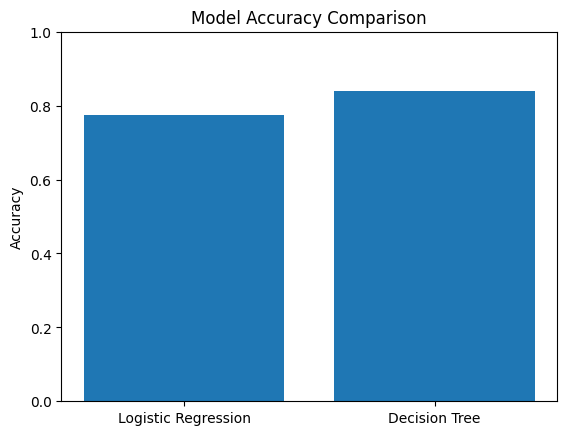

In [56]:
import matplotlib.pyplot as plt

# Your model accuracies
models = ["Logistic Regression", "Decision Tree"]
accuracy = [0.7758, 0.8394]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Conclusion

Overall, the Decision Tree model performed better than Logistic Regression for this classification task.  

Logistic Regression is simpler and easier to interpret, but it struggled with more complex relationships in the data. The Decision Tree handled those patterns better, leading to higher accuracy.

This shows that nonlinear models may be more suitable for real estate price classification problems.